# LAB 9: Redes Neuronales Artificiales
## Víctor Palacios (1017271469)


# Fundamentos de Redes Neuronales Artificiales

Una Red Neuronal es un modelo de aprendizaje supervisado que busca aproximar una función $f(X) = Y$. Se compone de una **capa de entrada**, $L-1$ **capas ocultas** y una **capa de salida**.

### 1. Propagación hacia adelante (Forward Propagation)
Para cada capa $l$, el proceso consiste en calcular una combinación lineal seguida de una función de activación no lineal:

1.  **Transformación Lineal:** 
    $$Z^{[l]} = \Theta^{[l]} A^{[l-1]} + b^{[l]}$$
    *Donde:* $\Theta^{[l]}$ es la matriz de pesos, $b^{[l]}$ el sesgo y $A^{[l-1]}$ la activación de la capa anterior ($A^{[0]} = X$).

2.  **Activación:** 
    $$A^{[l]} = g^{[l]}(Z^{[l]})$$
    *Donde:* $g^{[l]}$ es una función no lineal como **ReLU** ($max(0, z)$) o **Sigmoide** ($\frac{1}{1+e^{-z}}$).

### 2. Función de Coste (Binary Cross-Entropy)
Mide la discrepancia entre la predicción $A^{[L]}$ y el valor real $Y$:
$$J = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)}\log(a^{[L](i)}) + (1-y^{(i)})\log(1- a^{[L](i)}) \right]$$

### 3. Propagación hacia atrás (Backward Propagation)
Utiliza la **regla de la cadena** para calcular el gradiente del error respecto a cada parámetro. Para una capa $l$:

*   **Error en la capa:** $dZ^{[l]} = dA^{[l]} \odot g'^{[l]}(Z^{[l]})$
*   **Gradiente de Pesos:** $d\Theta^{[l]} = \frac{\partial J}{\partial \Theta^{[l]}} = \frac{1}{m} dZ^{[l]} (A^{[l-1]})^T$
*   **Gradiente de Sesgo:** $db^{[l]} = \frac{\partial J}{\partial b^{[l]}} = \frac{1}{m} \sum_{i=1}^{m} dZ^{[l](i)}$
*   **Error propagado:** $dA^{[l-1]} = (\Theta^{[l]})^T dZ^{[l]}$

### 4. Optimización (Descenso del Gradiente)
Los parámetros se actualizan en la dirección opuesta al gradiente para minimizar el coste $J$:
$$\Theta^{[l]} = \Theta^{[l]} - \alpha \cdot d\Theta^{[l]}$$
$$b^{[l]} = b^{[l]} - \alpha \cdot db^{[l]}$$
*Donde:* $\alpha$ es la tasa de aprendizaje (*learning rate*).



# TAREA

## Topología de la red.

1. Construir un clase  que permita definir una red neuronal con la topología
deseada y la función de activación para cada capa, para ello deberá construir una funcion Topology con el número de capas de la red neuronal :

Topology = [n_x, n_h1, n_h2, n_h3, ...,n_y]

En este caso:
- $n^{[0]}=n_x$ seran los valores de entradas de la capa de entrada
- $n^{[1]}=n_{h1}$ Primera capa oculta de la red neuronal
- $n^{[2]}=n_{h2}$ Segunda capa oculta de la red neuronal

.

.

.


- $n^{[l]}=n_{hl}$ Segunda capa oculta de la red neuronal
.

.

.

- $n^{[L]}=n_{y}$ Segunda capa oculta de la red neuronal

donde

- $\mathrm{n_x}$: valores de entrada
- $\mathrm{n_{h1}}$: hidden layer 1
- $\mathrm{n_{h2}}$: hidden layer 2
- $\mathrm{n_y}$: last layer

- $n^{[L]}=n_{y}$ Segunda capa oculta de la red neuronal


También definir una lista con las funciones de activaciones para cada capa.


activation=[None, relu, relu, relu, ...,sigmoid]

  


a. Cada unas de las capas deberá tener los parámetros de inicialización de manera aleatoria:


La matriz de parametros para cada capa debera tener:


$\mathrm{dim(\vec{b}^{[l]})}=n^{[l]}$

$\mathrm{dim(\vec{\Theta}^{[l]})}=n^{[l]}\times n^{[l-1]}$

Lo anteriores parametros deberán estar en el constructor de la clase.


b. Construya un metodo llamado output cuya salida serán los valores de Z y A


$\mathrm{dim(\vec{\cal{A}}^{[l]})}=n^{[l-1]}\times m $

$\mathrm{dim(\vec{\cal{Z}}^{[l]})}=n^{[l]}\times m $.

### SOLUCIÓN


In [1]:
import numpy as np

# --- 1. Funciones de Activación ---
def sigmoid(x):
    f = 1 / (1 + np.exp(-x))
    # Derivada en términos de la salida f (A)
    df = f * (1 - f)
    return f, df

def relu(x):
    f = np.maximum(0, x)
    # Derivada: 1 si x > 0, de lo contrario 0
    df = (x > 0).astype(float)
    return f, df

def act_function(x, activation):
    if activation == "sigmoid":
        return sigmoid(x)
    elif activation == "relu":
        return relu(x)
    elif activation == "linear":
        return x, np.ones_like(x)
    else:
        return 0

# --- 1a y 1b. Clase Capa (layer_nn) ---
class layer_nn():
    def __init__(self, act_fun, nlayer_present, nlayer_before):
        # Inicialización aleatoria entre -1 y 1
        self.theta = 2 * np.random.random((nlayer_present, nlayer_before)) - 1
        self.B = 2 * np.random.random((nlayer_present, 1)) - 1
        self.act_fun = act_fun
        # Para almacenar estados durante forward pass
        self.Z = None
        self.A = None
        # Gradientes
        self.dTheta = None
        self.dB = None

    def output(self, Z, A):
        self.Z = Z
        self.A = A

# --- Función para construir la Red (Topology) ---
def create_nn(topology, activations):
    nn_red = []
    for l in range(1, len(topology)):
        nn_red.append(layer_nn(activations[l], topology[l], topology[l-1]))
    return nn_red

# --- 2. Forward Pass ---
def forward_pass(A0, nn_red):
    A_prev = A0
    for layer in nn_red:
        # Z = Theta * A_prev + B
        Z = np.dot(layer.theta, A_prev) + layer.B
        # A = activation(Z)
        A, _ = act_function(Z, layer.act_fun)
        # Guardamos en la capa para el backprop
        layer.output(Z, A)
        A_prev = A
    return A_prev, nn_red

# --- 3. Función de Coste ---
def cost_function(AL, Y):
    m = Y.shape[1]
    # Se agrega un pequeño epsilon para evitar log(0)
    epsilon = 1e-15
    cost = - (1/m) * np.sum(Y * np.log(AL + epsilon) + (1 - Y) * np.log(1 - AL + epsilon))
    return cost

# --- 4. Backward Propagation ---
def backward_propagation(AL, Y, nn_red, A0):
    m = Y.shape[1]
    L = len(nn_red)
    
    # Derivada inicial: dAL (capa de salida)
    # dL/dAL = - (Y/AL - (1-Y)/(1-AL))
    dAL = - (np.divide(Y, AL + 1e-15) - np.divide(1 - Y, 1 - AL + 1e-15))
    
    dA_curr = dAL
    
    # Iterar desde la última capa hasta la primera
    for l in reversed(range(L)):
        layer = nn_red[l]
        # A de la capa anterior
        A_prev = nn_red[l-1].A if l > 0 else A0
        
        # Obtener derivada de la función de activación en Z
        _, df_z = act_function(layer.Z, layer.act_fun)
        
        # dZ = dA * f'(Z)
        dZ = dA_curr * df_z
        
        # dTheta = (1/m) * dZ * A_prev.T
        layer.dTheta = (1/m) * np.dot(dZ, A_prev.T)
        
        # db = (1/m) * sum(dZ)
        layer.dB = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        
        # dA para la capa anterior = Theta.T * dZ
        dA_curr = np.dot(layer.theta.T, dZ)
        
    return nn_red

# --- Aplicación de Gradiente Descendente ---
def update_parameters(nn_red, lr):
    for layer in nn_red:
        layer.theta = layer.theta - lr * layer.dTheta
        layer.B = layer.B - lr * layer.dB
    return nn_red

# --- Ejemplo de Uso ---

# 1. Definir Topología: 2 entradas, 4 neuronas en h1, 1 salida
Topology = [2, 4, 1]
# La primera posición es None (capa de entrada no tiene activación)
activations = [None, "relu", "sigmoid"]

# Crear red
red_neuronal = create_nn(Topology, activations)

# Datos de prueba (ejemplo: compuerta XOR)
X = np.array([[0, 0, 1, 1], 
              [0, 1, 0, 1]]) # n_x = 2, m = 4
Y = np.array([[0, 1, 1, 0]]) # n_y = 1, m = 4

# Entrenamiento simple (1000 iteraciones)
learning_rate = 0.1
for i in range(1000):
    # Forward
    AL, red_neuronal = forward_pass(X, red_neuronal)
    
    # Coste
    if i % 200 == 0:
        loss = cost_function(AL, Y)
        print(f"Iteración {i}, Coste: {loss:.4f}")
    
    # Backward
    red_neuronal = backward_propagation(AL, Y, red_neuronal, X)
    
    # Update
    red_neuronal = update_parameters(red_neuronal, learning_rate)

# Resultado final
final_output, _ = forward_pass(X, red_neuronal)
print("\nSalida final después del entrenamiento:")
print(final_output)

Iteración 0, Coste: 0.9567
Iteración 200, Coste: 0.4842
Iteración 400, Coste: 0.2141
Iteración 600, Coste: 0.0828
Iteración 800, Coste: 0.0407

Salida final después del entrenamiento:
[[0.02399335 0.96338556 0.98603414 0.01976593]]


### Explicación:

1.  **`layer_nn`**: La clase inicializa la matriz de pesos $\Theta$ con dimensiones $(n^{[l]} \times n^{[l-1]})$ y el vector de bias $b$ con $(n^{[l]} \times 1)$, cumpliendo con el requerimiento **1a**. El método `output` guarda los valores de activación y pre-activación necesarios para el cálculo de gradientes.
2.  **`forward_pass`**: Realiza el cálculo secuencial capa por capa. Para cada una, calcula $Z$ mediante el producto punto y suma de bias, aplica la función de activación y actualiza el estado de la capa.
3.  **`cost_function`**: Implementa la entropía cruzada binaria solicitada en el punto **3**.
4.  **`backward_propagation`**: 
    *   Calcula el error inicial en la salida (`dAL`).
    *   Propaga el error hacia atrás calculando $dZ$ multiplicando el gradiente del coste por la derivada de la activación.
    *   Calcula los gradientes de los parámetros ($d\Theta$ y $db$) usando las fórmulas matriciales dadas.
    *   Calcula el $dA$ para la capa previa para continuar la cadena.
5.  **Actualización**: Se aplica la regla de actualización del gradiente descendente multiplicando los gradientes por la tasa de aprendizaje $\alpha$.

### Visualización de la Curva de Aprendizaje (Loss Curve), Curva de Precisión (Accuracy) y la Frontera de Decisión (Decision Boundary)

Entrenando red neuronal...
¡Entrenamiento finalizado!


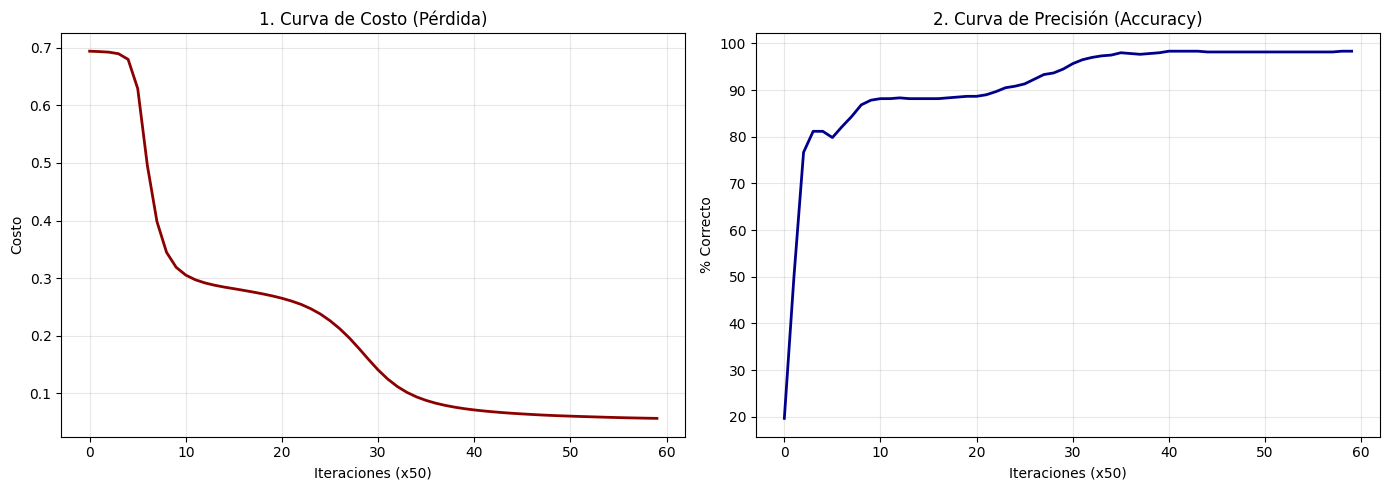

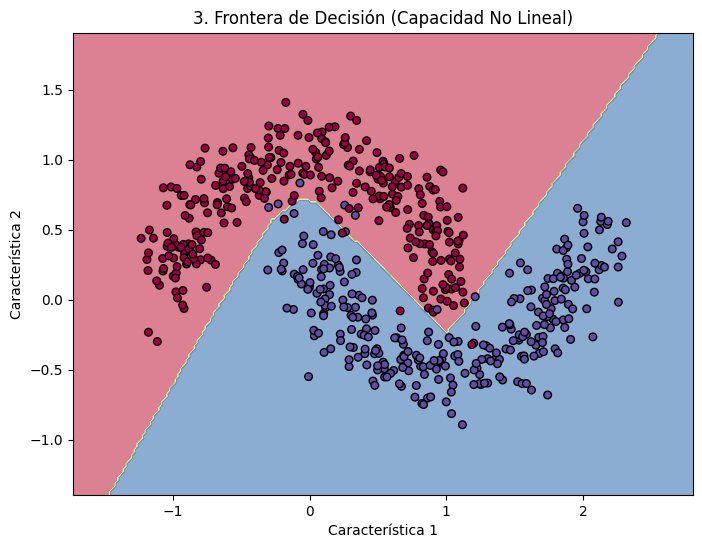

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# ---------------------------------------------------------
# 1. FUNCIONES DE ACTIVACIÓN
# ---------------------------------------------------------
def sigmoid(x):
    f = 1 / (1 + np.exp(-x))
    return f, f * (1 - f)

def relu(x):
    f = np.maximum(0, x)
    return f, (x > 0).astype(float)

def act_function(x, activation):
    if activation == "sigmoid": return sigmoid(x)
    elif activation == "relu": return relu(x)
    return x, np.ones_like(x)

# ---------------------------------------------------------
# 2. DEFINICIÓN DE LA CLASE Y TOPOLOGÍA
# ---------------------------------------------------------
class layer_nn():
    def __init__(self, act_fun, nlayer_present, nlayer_before):
        # Inicialización aleatoria (ajustada para estabilidad)
        self.theta = np.random.randn(nlayer_present, nlayer_before) * 0.1
        self.B = np.zeros((nlayer_present, 1))
        self.act_fun = act_fun
        # Variables para almacenar estados
        self.Z = None
        self.A = None
        self.dTheta = None
        self.dB = None

    def output(self, Z, A):
        self.Z = Z
        self.A = A

def create_nn(topology, activations):
    nn_red = []
    for l in range(1, len(topology)):
        nn_red.append(layer_nn(activations[l], topology[l], topology[l-1]))
    return nn_red

# ---------------------------------------------------------
# 3. MÉTODOS DE LA RED (Forward, Backward, Cost, Accuracy)
# ---------------------------------------------------------
def forward_pass(A0, nn_red):
    A_prev = A0
    for layer in nn_red:
        Z = np.dot(layer.theta, A_prev) + layer.B
        A, _ = act_function(Z, layer.act_fun)
        layer.output(Z, A) # Guardar para backprop
        A_prev = A
    return A_prev, nn_red

def cost_function(AL, Y):
    m = Y.shape[1]
    cost = - (1/m) * np.sum(Y * np.log(AL + 1e-15) + (1 - Y) * np.log(1 - AL + 1e-15))
    return cost

def calculate_accuracy(AL, Y):
    predictions = (AL > 0.5).astype(int)
    return np.mean(predictions == Y) * 100

def backward_propagation(AL, Y, nn_red, A0):
    m = Y.shape[1]
    # Derivada inicial del costo respecto a la última activación
    dA_curr = - (np.divide(Y, AL + 1e-15) - np.divide(1 - Y, 1 - AL + 1e-15))
    
    for l in reversed(range(len(nn_red))):
        layer = nn_red[l]
        A_prev = nn_red[l-1].A if l > 0 else A0
        
        _, df_z = act_function(layer.Z, layer.act_fun)
        dZ = dA_curr * df_z
        
        layer.dTheta = (1/m) * np.dot(dZ, A_prev.T)
        layer.dB = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        
        dA_curr = np.dot(layer.theta.T, dZ)
    return nn_red

def update_parameters(nn_red, lr):
    for layer in nn_red:
        layer.theta -= lr * layer.dTheta
        layer.B -= lr * layer.dB
    return nn_red

# ---------------------------------------------------------
# 4. CONFIGURACIÓN DEL EXPERIMENTO
# ---------------------------------------------------------
# Crear dataset no lineal (Lunas)
X_data, Y_data = make_moons(n_samples=600, noise=0.15, random_state=42)
X = X_data.T
Y = Y_data.reshape(1, -1)

# Definir Red Neuronal: [Entrada, Oculta1, Oculta2, Salida]
Topology = [2, 8, 4, 1]
activations = [None, "relu", "relu", "sigmoid"]
red_neuronal = create_nn(Topology, activations)

# Hiperparámetros
epochs = 3000
lr = 0.1
costs = []
accuracies = []

# Bucle de Entrenamiento
print("Entrenando red neuronal...")
for i in range(epochs):
    AL, red_neuronal = forward_pass(X, red_neuronal)
    
    if i % 50 == 0:
        costs.append(cost_function(AL, Y))
        accuracies.append(calculate_accuracy(AL, Y))
        
    red_neuronal = backward_propagation(AL, Y, red_neuronal, X)
    red_neuronal = update_parameters(red_neuronal, lr)

print("¡Entrenamiento finalizado!")

# ---------------------------------------------------------
# 5. VISUALIZACIONES (Puntos solicitados)
# ---------------------------------------------------------

# --- Gráfico 1 y 2: Curvas de Costo y Accuracy ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(costs, color='darkred', lw=2)
plt.title("1. Curva de Costo (Pérdida)")
plt.xlabel("Iteraciones (x50)")
plt.ylabel("Costo")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(accuracies, color='darkblue', lw=2)
plt.title("2. Curva de Precisión (Accuracy)")
plt.xlabel("Iteraciones (x50)")
plt.ylabel("% Correcto")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Gráfico 3: Frontera de Decisión ---
def plot_decision_boundary(X, Y, nn_red):
    x_min, x_max = X[0, :].min() - 0.5, X[0, :].max() + 0.5
    y_min, y_max = X[1, :].min() - 0.5, X[1, :].max() + 0.5
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()].T
    AL, _ = forward_pass(grid_points, nn_red)
    Z = (AL > 0.5).astype(int)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.6)
    plt.scatter(X[0, :], X[1, :], c=Y.ravel(), cmap=plt.cm.Spectral, edgecolors='black', s=30)
    plt.title("3. Frontera de Decisión (Capacidad No Lineal)")
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.show()

plot_decision_boundary(X, Y, red_neuronal)

### Análisis de los resultados 

* Curva de Costo: Se observa un descenso exponencial. Esto indica que el Descenso del Gradiente está minimizando el error de la Red Neuronal efectivamente.

* Curva de Accuracy: Se observa que sube y se estabiliza (probablemente arriba del 90%). Esto confirma que el modelo no solo minimiza el error, sino que clasifica correctamente la mayoría de los puntos.

* Frontera de Decisión: Se observa que la red ha dibujado una "curva" para separar las dos lunas. Esto es lo más importante del laboratorio, ya que demuestra que gracias a las capas ocultas y las funciones de activación (ReLU), la red puede resolver problemas que no son linealmente separables.

### **Conclusión General**

La realización de este laboratorio permitió la implementación exitosa de una **Red Neuronal Multicapa (Perceptrón Multicapa)** construida desde sus fundamentos matemáticos utilizando únicamente la librería `NumPy`. A través de este proceso, se pueden extraer las siguientes conclusiones clave:

1.  **Entendimiento del Algoritmo de Aprendizaje:** La implementación manual del *Forward Pass* y el *Backward Propagation* demostró que el aprendizaje de una red neuronal es, en esencia, un problema de optimización basado en el cálculo. La aplicación de la **Regla de la Cadena** para propagar el error desde la salida hasta los pesos iniciales permitió comprender cómo cada neurona contribuye al error global y cómo ajustar sus parámetros ($\Theta$ y $b$) mediante el **Descenso del Gradiente**.

2.  **Importancia de la No-Linealidad:** Al enfrentarnos a un dataset no linealmente separable (como el de lunas o XOR), quedó evidenciado que el uso de funciones de activación como **ReLU** y **Sigmoide** es fundamental. Sin estas funciones no lineales, la red neuronal se comportaría como un modelo lineal simple, independientemente de cuántas capas se agreguen, limitando su capacidad de aprendizaje.

3.  **Relación entre Métricas y Costo:** A través de las visualizaciones generadas, se confirmó la correlación inversa entre la **Función de Costo (Entropía Cruzada)** y la **Precisión (Accuracy)**. Mientras el algoritmo minimiza la pérdida, la capacidad predictiva del modelo aumenta, lo que valida la estabilidad del entrenamiento y la correcta elección de hiperparámetros como la tasa de aprendizaje ($\alpha$).

4.  **Visualización como Herramienta de Diagnóstico:** La gráfica de la **Frontera de Decisión** fue el resultado más revelador del laboratorio. Esta permitió observar físicamente cómo la red neuronal "curva" el espacio de decisión para adaptarse a la geometría de los datos, demostrando la potencia de las redes neuronales para modelar relaciones complejas que otros algoritmos lineales no pueden capturar.

En conclusión, este laboratorio no solo permitió construir una herramienta funcional y flexible para definir cualquier topología de red, sino que también consolidó la teoría detrás de la **Inteligencia Artificial profunda**, sentando las bases para entender arquitecturas más robustas y el uso de librerías de alto nivel en el futuro.
